# Double descent

The scaling notebooks train in a single pass: every example is seen once, so the model
never overfits and the loss decreases monotonically. This notebook does the opposite: it
trains repeatedly on a fixed dataset until the model interpolates it, with more label noise
($\sigma=0.4$), on the same Gaussian teacher (width 256, two hidden layers). In this
data-limited regime the test loss shows **double descent**.

The test loss is the MSE against held-out *noisy* labels $y=f(x)+\sigma\varepsilon$, so it
has the same floor $E=\sigma^2$ as the training loss and the two can be compared directly
(we compute it as the noise-free excess risk plus $\sigma^2$). The test loss peaks where
the model is just able to fit the noisy training points. Each plot also shows the
**early-stopped** loss, i.e. the minimum test loss over training (an oracle early stop).

> Training is done by `scripts/run_double_descent.py` (`--mode width|samples|epochs|grid`);
> this notebook loads the cached CSVs and plots them.

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from scaling_laws import plotting as pl
pl.set_style()

RESULTS = Path("../results").resolve(); FIGDIR = RESULTS / "figures"
SIGMA = 0.4
df_s = pd.read_csv(os.path.join(RESULTS, "double_descent_samples.csv"))
df_w = pd.read_csv(os.path.join(RESULTS, "double_descent_width.csv"))
df_e = pd.read_csv(os.path.join(RESULTS, "double_descent_epochs.csv"))
N256 = int(df_s["N"].iloc[0])                 # params of the W=256 model
print(f"W=256 has N={N256:,} params;  sigma={SIGMA} (noise var {SIGMA**2})")

W=256 has N=74,497 params;  sigma=0.4 (noise var 0.16000000000000003)


## 1. Model-wise: varying the width $W$

We fix the dataset at $D{=}10{,}000$ examples, vary the width $W$ (and with it $N$), and
train each model to interpolation
([`run_double_descent.py --mode width`](../scripts/run_double_descent.py)).

The curve has the classic shape: a U for small models, a sharp peak at the interpolation
threshold $N\approx D$ (here $W{\approx}80$, where the training error drops to about zero),
and a second descent for larger, overparameterized models. The early-stopped curve (green)
has no peak.

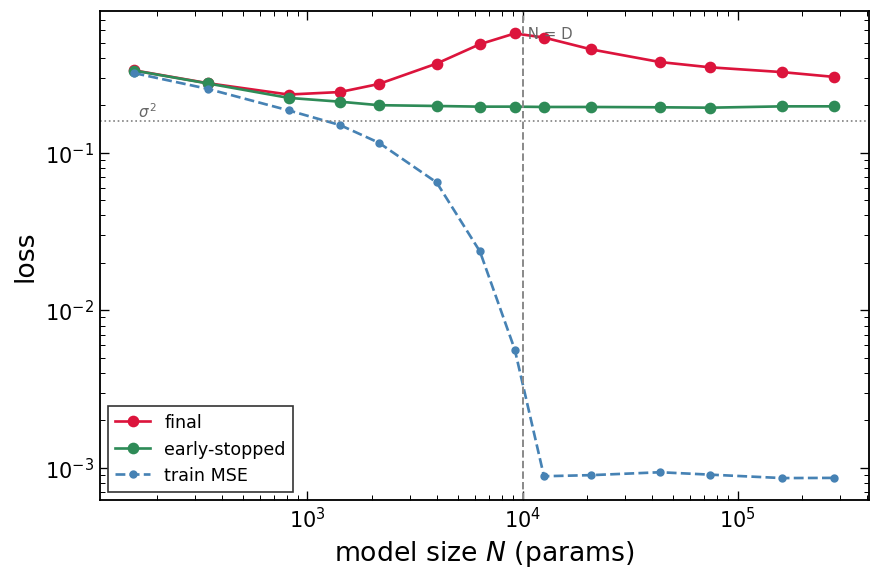

In [2]:
Dfix = int(df_w["D"].iloc[0])
fig = pl.plot_dd_final(df_w, axis="N", threshold=Dfix, threshold_label="N = D", sigma=SIGMA, train="overlay")
pl.save_figure(fig, "double_descent_width", outdir=FIGDIR); plt.show()

## 2. Sample-wise: varying the dataset size $D$

Now we fix the model ($W{=}256$) and vary the size $D$ of the fixed, repeated dataset.
Each model is trained to interpolation, and we record both the final and the early-stopped
test loss ([`run_double_descent.py --mode samples`](../scripts/run_double_descent.py)).

The test loss rises to a peak near the interpolation threshold $D\approx N$, where the
model can just fit the noise, and then decreases again toward the $\sigma^2$ floor. Again
the early-stopped curve (green) has no peak.

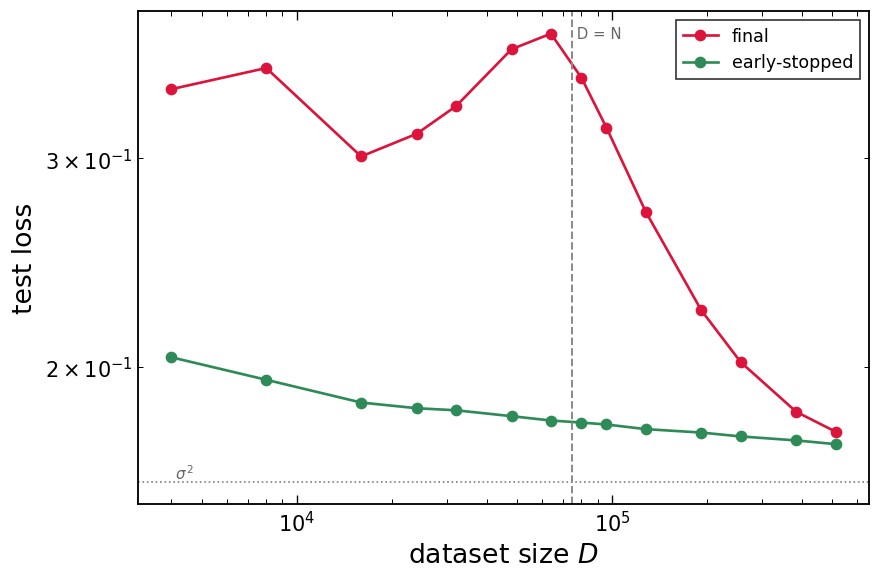

In [3]:
fig = pl.plot_dd_final(df_s, axis="D", threshold=N256, threshold_label="D = N", sigma=SIGMA, train="none")
pl.save_figure(fig, "double_descent_samples", outdir=FIGDIR); plt.show()

## 3. Epoch-wise: varying the training time

We fix $W{=}256$ and a dataset much smaller than the number of parameters, train for a long
time, and record the test and training loss along the way
([`run_double_descent.py --mode epochs`](../scripts/run_double_descent.py)).

The test loss first decreases (the model learns the teacher), then increases (it memorizes
the label noise), and then decreases again (the second descent), while the training MSE
(dashed) decreases monotonically until the model interpolates the data. The $\star$ marks
the minimum of each test curve, where an early stop would end training.

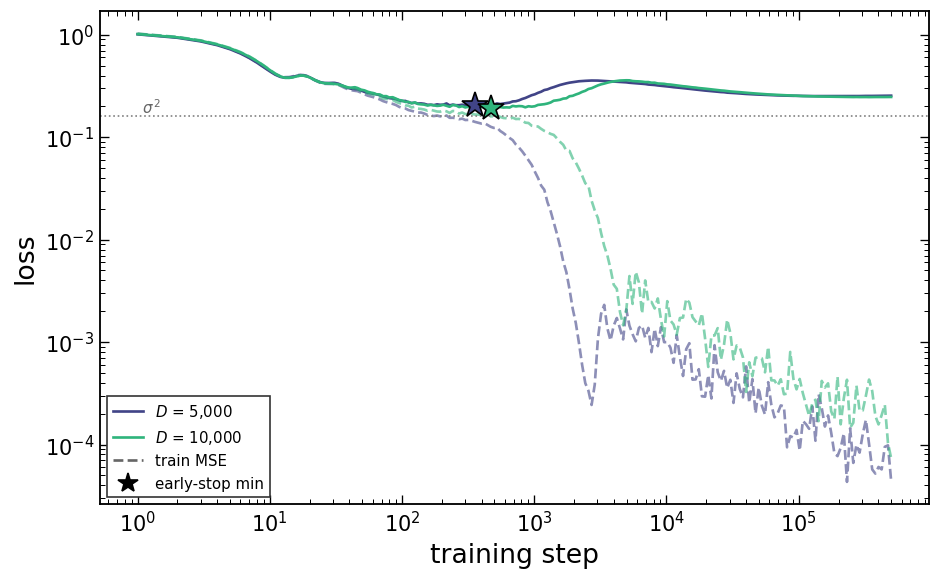

In [4]:
fig = pl.plot_dd_epochs(df_e, width=256, n_params=N256, sigma=SIGMA)
pl.save_figure(fig, "double_descent_epochs", outdir=FIGDIR); plt.show()

## 4. The full picture: a 2D phase diagram

The model-wise and sample-wise curves are one-dimensional cuts through the plane spanned by
model size $N$ and dataset size $D$. Here we sweep both axes (one seed), train every
$(W, D)$ cell to interpolation, and record the final test loss and training MSE
([`run_double_descent.py --mode grid`](../scripts/run_double_descent.py)).

The test loss has a bright ridge along $N\approx D$ (dashed), where the training MSE (right
panel) drops to zero. Moving away from the ridge, by adding data (up) or capacity (right),
lowers the test loss again. The model-wise curve is a horizontal cut through this plane
(fixed $D$), the sample-wise curve a vertical one (fixed $W$).

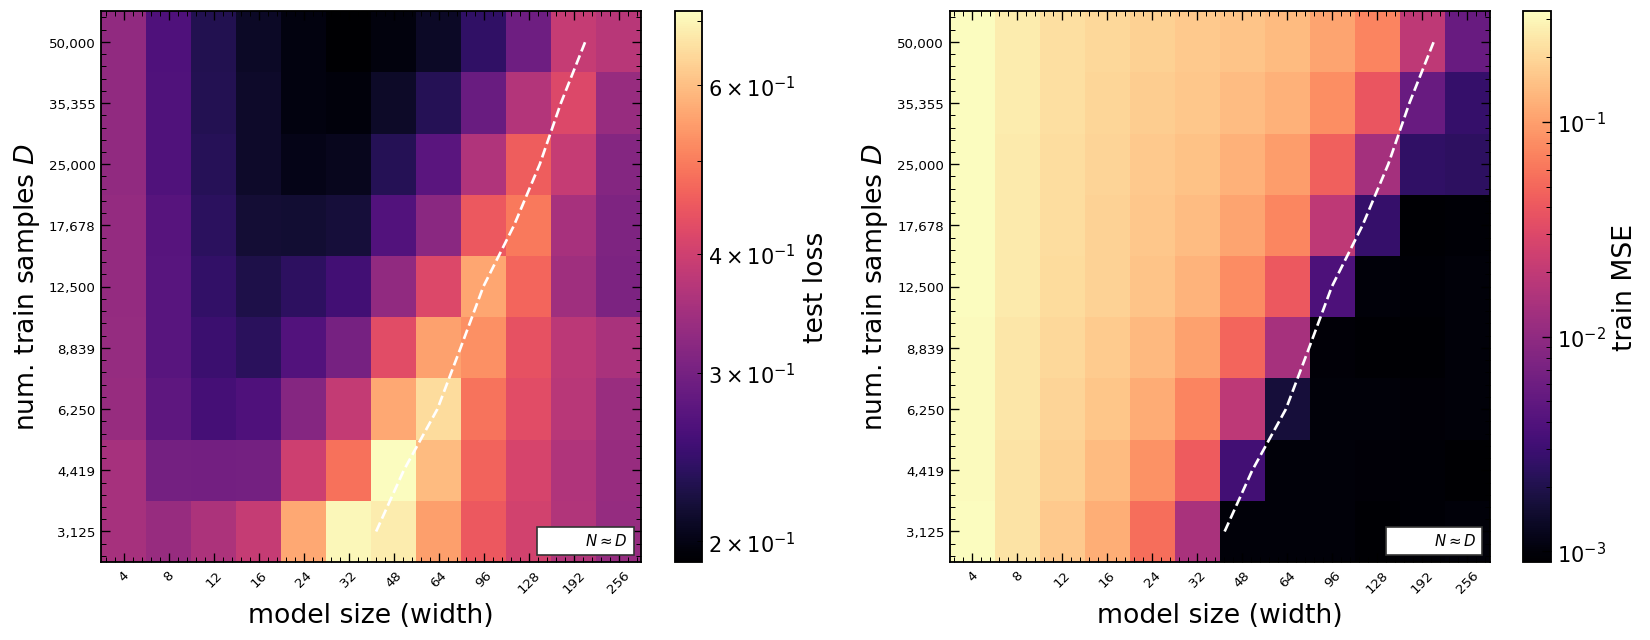

In [5]:
df_g = pd.read_csv(os.path.join(RESULTS, "double_descent_grid.csv"))
fig = pl.plot_dd_phase(df_g, sigma=SIGMA)
pl.save_figure(fig, "double_descent_phase", outdir=FIGDIR); plt.show()

## Summary

- Increasing the data, the model size, or the training time leads to the same behavior:
  the test loss peaks around the interpolation threshold, where the model can just fit the
  noisy data, and decreases again beyond it.
- In the model-wise and sample-wise cases, and in the phase diagram, the test peak
  coincides with the training error reaching zero.
- Early stopping removes the peak: the early-stopped loss (green curves and stars) is
  nearly flat across the threshold.
- The scaling notebooks avoid this regime by construction. Single-pass training never
  repeats data, so the model never interpolates a finite dataset and the loss decreases
  monotonically. Double descent is a feature of training on a finite, repeated dataset; it
  does not appear when every example is new.

### Reproducing the results
```bash
python scripts/run_double_descent.py --mode width     # ~6 min
python scripts/run_double_descent.py --mode samples   # ~25 min
python scripts/run_double_descent.py --mode epochs --max-steps 500000   # ~40 min
python scripts/run_double_descent.py --mode grid
```